# Forecasting Sales E-Commerce Harian (Global E-Commerce Dataset)

**Studi Kasus:** Forecasting (Peramalan)
**Dataset:** Global E-Commerce Forecasting Dataset (transaksi, indikator ekonomi negara, periode Des 2009 - Des 2010)

**Sumber Dataset:** *https://www.kaggle.com/datasets/algozee/multi-source-data-for-e-commerce-sales-prediction*

---

## 1. Business Understanding

### Latar Belakang Masalah
Perusahaan e-commerce beroperasi di banyak negara dengan kondisi ekonomi yang berbeda-beda
(GDP growth, inflasi, jumlah populasi). Total penjualan harian (`sales_amount_gbp`) sangat
fluktuatif karena dipengaruhi oleh jumlah unit terjual, harga satuan, musim/waktu (hari, bulan),
serta kondisi makroekonomi negara tempat transaksi terjadi. Tanpa adanya model peramalan,
pihak manajemen kesulitan memperkirakan pendapatan harian untuk kebutuhan perencanaan stok,
arus kas, dan strategi promosi.

### Tujuan Project
Membangun model **forecasting (regresi time series)** untuk memprediksi total penjualan harian
(`sales_amount_gbp`) berdasarkan fitur historis penjualan, karakteristik transaksi, dan indikator
ekonomi negara.

### Manfaat Analisis
- Membantu tim bisnis memperkirakan pendapatan harian untuk beberapa hari ke depan.
- Membantu perencanaan stok dan strategi pemasaran berdasarkan tren penjualan dan musim.
- Memberikan gambaran pengaruh kondisi ekonomi (inflasi, GDP growth) terhadap penjualan.

In [1]:
# --------------------------- IMPORT LIBRARY ---------------------------
import pandas as pd             # Untuk manipulasi dan analisis data tabular (DataFrame)
import numpy as np              # Untuk operasi matematika dan array multidimensi
import matplotlib.pyplot as plt # Library utama untuk membuat grafik dan visualisasi
import seaborn as sns           # Library visualisasi data yang lebih cantik dan modern

# Import modul dari Scikit-Learn (Machine Learning)
from sklearn.linear_model import LinearRegression       # Model Linear Regression (baseline)
from sklearn.ensemble import RandomForestRegressor       # Model Random Forest (model utama)
from sklearn.model_selection import train_test_split    # (tidak dipakai untuk split utama, time series)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Metrik evaluasi: MSE, MAE, dan R² Score
from sklearn.preprocessing import StandardScaler        # Untuk melakukan scaling/normalisasi data

# --------------------------- PENGATURAN AWAL ---------------------------
import warnings
warnings.filterwarnings('ignore')  # Menonaktifkan semua warning agar output lebih bersih

# --------------------------- PENGATURAN VISUALISASI ---------------------------
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Library berhasil diimport!")

Library berhasil diimport!


---
## 2. Data Understanding

Dataset berisi data transaksi e-commerce per item pesanan (`order_datetime`, `country`,
`product_id`, `quantity_sold`, `unit_price_gbp`, `sales_amount_gbp`) yang digabung dengan
indikator ekonomi negara (`population_total`, `gdp_current_usd`, `gdp_growth_pct`,
`inflation_consumer_pct`).

Karena model yang dibangun adalah **model forecasting harian per kelompok negara**, data
transaksi ini akan diagregasi menjadi satu baris per **(tanggal, kelompok negara)**.

In [2]:
# Memuat dataset dari file CSV
df_raw = pd.read_csv('global_ecommerce_forecasting.csv')

# --------------------------- AGREGASI HARIAN PER NEGARA ---------------------------
# 1. Pastikan kolom 'order_datetime' bertipe datetime
df_raw['order_datetime'] = pd.to_datetime(df_raw['order_datetime'], errors='coerce')

# 2. Buat kolom 'date' (tanpa jam) sebagai dasar agregasi harian
df_raw['date'] = df_raw['order_datetime'].dt.floor('D')

# 3. ENCODING AWAL: kelompokkan negara menjadi 5 negara dengan transaksi terbanyak,
#    sisanya digabung jadi kategori 'Other'. Ini diperlukan agar fitur kategorikal
#    'country_group' punya jumlah data yang cukup di tiap kategori saat di-encode nanti.
top5 = df_raw['country'].value_counts().head(5).index.tolist()
df_raw['country_group'] = np.where(df_raw['country'].isin(top5), df_raw['country'], 'Other')

print("5 negara dengan transaksi terbanyak:", top5)

# 4. Agregasi harian per (date, country_group):
#    - sales_amount_gbp -> dijumlahkan (total penjualan per hari per kelompok negara)
#    - quantity_sold    -> dijumlahkan (total unit terjual)
#    - unit_price_gbp   -> dirata-rata (harga rata-rata)
#    - gdp_growth_pct, inflation_consumer_pct, population_total -> dirata-rata
df = df_raw.groupby(['date', 'country_group'], as_index=False).agg(
    sales_amount_gbp=('sales_amount_gbp', 'sum'),
    quantity_sold=('quantity_sold', 'sum'),
    unit_price_gbp=('unit_price_gbp', 'mean'),
    gdp_growth_pct=('gdp_growth_pct', 'mean'),
    inflation_consumer_pct=('inflation_consumer_pct', 'mean'),
    population_total=('population_total', 'mean')
)

# --------------------------- INFORMASI DATASET ---------------------------
print("="*50)
print("INFORMASI DATASET (setelah agregasi harian per negara)")
print("="*50)
print(f"Shape Dataset         : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Kolom yang tersedia   : {list(df.columns)}")
print("\nTipe Data:")
print(df.dtypes)
print("\n5 Baris Data Pertama:")
print(df.head())
print("\n5 Baris Data Terakhir:")
print(df.tail())

5 negara dengan transaksi terbanyak: ['United Kingdom', 'Ireland', 'Germany', 'France', 'Netherlands']
INFORMASI DATASET (setelah agregasi harian per negara)
Shape Dataset         : 1,116 baris x 8 kolom
Kolom yang tersedia   : ['date', 'country_group', 'sales_amount_gbp', 'quantity_sold', 'unit_price_gbp', 'gdp_growth_pct', 'inflation_consumer_pct', 'population_total']

Tipe Data:
date                      datetime64[ns]
country_group                     object
sales_amount_gbp                 float64
quantity_sold                      int64
unit_price_gbp                   float64
gdp_growth_pct                   float64
inflation_consumer_pct           float64
population_total                 float64
dtype: object

5 Baris Data Pertama:
        date   country_group  sales_amount_gbp  quantity_sold  unit_price_gbp  \
0 2009-12-01          France           1030.24            661        3.207500   
1 2009-12-01         Germany            929.92            484        3.159773   
2 2009-

In [3]:
# Identifikasi Data Kotor

# Mengecek jumlah missing values (data yang kosong) di setiap kolom
print("\nMissing Values per Kolom:")
print(df.isnull().sum())

# Penjelasan:
# df.isnull()    -> Mengembalikan DataFrame dengan nilai True/False
# .sum()         -> Menjumlahkan nilai True (missing) per kolom
# Hasilnya menunjukkan berapa banyak data yang hilang di tiap kolom


Missing Values per Kolom:
date                      0
country_group             0
sales_amount_gbp          0
quantity_sold             0
unit_price_gbp            0
gdp_growth_pct            0
inflation_consumer_pct    0
population_total          0
dtype: int64


In [4]:
# Menampilkan informasi lengkap dan statistik deskriptif
print("\nInformasi Lengkap Dataset:")
df.info()

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nDistribusi country_group:")
print(df['country_group'].value_counts())


Informasi Lengkap Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    1116 non-null   datetime64[ns]
 1   country_group           1116 non-null   object        
 2   sales_amount_gbp        1116 non-null   float64       
 3   quantity_sold           1116 non-null   int64         
 4   unit_price_gbp          1116 non-null   float64       
 5   gdp_growth_pct          1116 non-null   float64       
 6   inflation_consumer_pct  1116 non-null   float64       
 7   population_total        1116 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 69.9+ KB

Statistik Deskriptif:
                                date  sales_amount_gbp  quantity_sold  \
count                           1116       1116.000000    1116.000000   
mean   2010-06-

In [5]:

# ======================================================================
# PENGECEKAN DATA DUPLIKAT
# ======================================================================

print(f"\nBaris Duplikat : {df.duplicated().sum()}")

# Penjelasan:
# df.duplicated()  -> Mengembalikan Series dengan nilai True untuk baris yang duplikat
# .sum()           -> Menghitung berapa banyak baris yang bernilai True (duplikat)


Baris Duplikat : 0


In [6]:
# ======================================================================
# PENGECEKAN NILAI TIDAK MASUK AKAL (OUTLIER LOGIS) - SALES AMOUNT
# ======================================================================

print(f"\n Nilai Tidak Masuk Akal di Sales Amount (GBP):")
print(f" Sales Amount < 0 GBP      : {(df['sales_amount_gbp'] < 0).sum()} baris")
print(f" Sales Amount > 1.000.000  : {(df['sales_amount_gbp'] > 1_000_000).sum()} baris")

# Penjelasan:
# - Sales Amount di bawah 0   -> Bisa jadi kesalahan input (refund/retur ekstrem)
# - Sales Amount yang sangat ekstrem (>1.000.000) -> kemungkinan outlier/anomali


 Nilai Tidak Masuk Akal di Sales Amount (GBP):
 Sales Amount < 0 GBP      : 0 baris
 Sales Amount > 1.000.000  : 0 baris


In [7]:
# ======================================================================
# PENGECEKAN NILAI TIDAK MASUK AKAL (UNIT PRICE & QUANTITY SOLD)
# ======================================================================

print(f"\n Nilai Tidak Masuk Akal di Unit Price & Quantity Sold:")
print(f" Unit Price < 0 GBP   : {(df['unit_price_gbp'] < 0).sum()} baris")
print(f" Quantity Sold < 0    : {(df['quantity_sold'] < 0).sum()} baris")

# Penjelasan:
# Secara bisnis, harga satuan (unit_price_gbp) dan jumlah unit terjual
# (quantity_sold) tidak boleh bernilai negatif.


 Nilai Tidak Masuk Akal di Unit Price & Quantity Sold:
 Unit Price < 0 GBP   : 0 baris
 Quantity Sold < 0    : 0 baris


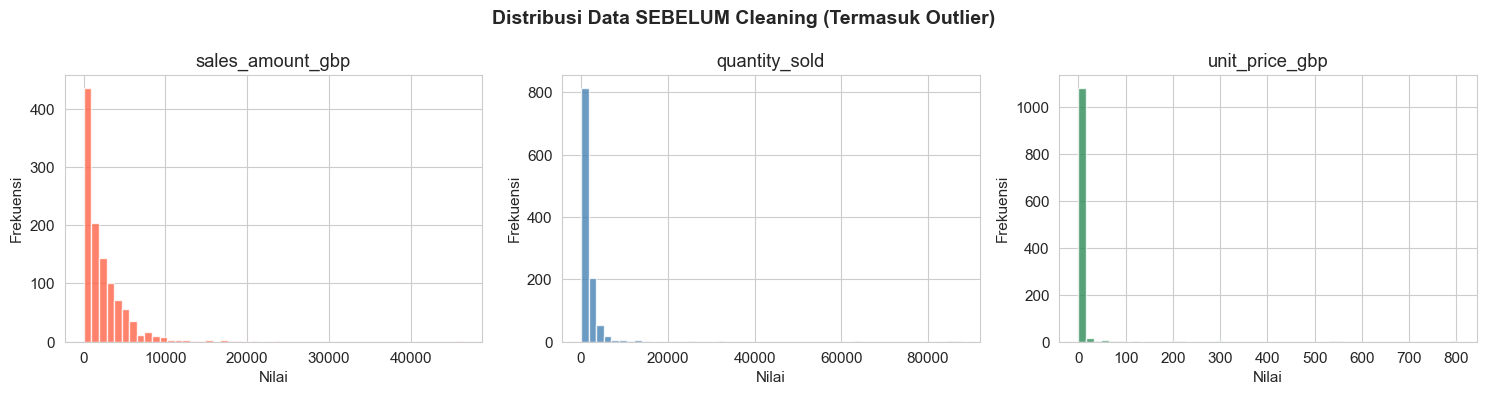

In [8]:
# Membuat figure dan 3 axes (subplot) secara bersamaan
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Data SEBELUM Cleaning (Termasuk Outlier)',
             fontsize=14, fontweight='bold')

for ax, col, color in zip(axes,
                          ['sales_amount_gbp', 'quantity_sold', 'unit_price_gbp'],
                          ['tomato', 'steelblue', 'seagreen']):
    df[col].dropna().hist(ax=ax, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

---
## 3. Data Preparation

Tahapan persiapan data meliputi: pembersihan duplikat, parsing & sorting tanggal,
penghapusan outlier, imputasi missing value, **encoding** fitur kategorikal
(`country_group`), serta **feature engineering** (fitur waktu dan fitur *lag*/historis).

In [9]:
# FASE 3 — Data Preparation

# Membuat salinan dataframe agar data asli (df) tidak berubah
df_clean = df.copy()

# --- Step 1: Hapus Duplikat ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Step 1 | Duplikat dihapus    : {before - len(df_clean)} baris")

Step 1 | Duplikat dihapus    : 0 baris


In [10]:
# --- Step 2: Parse & Sort Tanggal ---

df_clean['date'] = df_clean['date'].astype(str).str.strip()

# Format tanggal pada dataset ini adalah YYYY-MM-DD (ISO format), dayfirst=False
df_clean['date'] = pd.to_datetime(df_clean['date'],
                                  dayfirst=False,
                                  errors='coerce')

null_dates = df_clean['date'].isna().sum()
df_clean = df_clean.dropna(subset=['date'])

# Mengurutkan data berdasarkan negara lalu tanggal -> PENTING untuk fitur lag time series
df_clean = df_clean.sort_values(['country_group', 'date']).reset_index(drop=True)

print(f"Step 2 | Tanggal invalid     : {null_dates} baris dihapus, data diurutkan")

Step 2 | Tanggal invalid     : 0 baris dihapus, data diurutkan


In [11]:
# --- Step 3: Hapus Outlier Sales Amount ---

before = len(df_clean)
df_clean = df_clean[
    (df_clean['sales_amount_gbp'].isna()) |
    ((df_clean['sales_amount_gbp'] >= 0) & (df_clean['sales_amount_gbp'] <= 1_000_000))
]
print(f"Step 3 | Outlier Sales Amount : {before - len(df_clean)} baris dihapus")

Step 3 | Outlier Sales Amount : 0 baris dihapus


In [12]:
# --- Step 4: Hapus Outlier Unit Price & Quantity Sold ---

before = len(df_clean)
df_clean = df_clean[
    (df_clean['unit_price_gbp'].isna() | df_clean['quantity_sold'].isna()) |
    ((df_clean['unit_price_gbp'] >= 0) & (df_clean['quantity_sold'] >= 0))
]
print(f"Step 4 | Outlier Price/Qty    : {before - len(df_clean)} baris dihapus")

Step 4 | Outlier Price/Qty    : 0 baris dihapus


In [13]:
# --- Step 5: Imputasi Missing Values ---

num_cols = ['sales_amount_gbp', 'quantity_sold', 'unit_price_gbp',
             'gdp_growth_pct', 'inflation_consumer_pct', 'population_total']

miss_before = df_clean[num_cols].isna().sum().sum()

# Interpolasi linear dilakukan PER KELOMPOK NEGARA agar urutan waktu tetap konsisten
df_clean[num_cols] = (
    df_clean.groupby('country_group')[num_cols]
            .apply(lambda g: g.interpolate(method='linear'))
            .reset_index(drop=True)
)

df_clean = df_clean.dropna().reset_index(drop=True)

miss_after = df_clean[num_cols].isna().sum().sum()
print(f"Step 5 | Missing Values      : {miss_before} -> {miss_after}")

Step 5 | Missing Values      : 0 -> 0


In [14]:
# --- Step 6: Encoding Data Kategorikal ---

# Kolom 'country_group' adalah fitur kategorikal (nominal) yang merepresentasikan
# kelompok negara. Karena algoritma machine learning membutuhkan input numerik,
# kolom ini di-ENCODE menggunakan One-Hot Encoding (pd.get_dummies).
#
# drop_first=True -> salah satu kategori dijadikan baseline (dihindari multikolinearitas)

print("Kategori sebelum encoding:")
print(df_clean['country_group'].unique())

df_clean = pd.get_dummies(df_clean, columns=['country_group'], drop_first=True)

encoded_cols = [c for c in df_clean.columns if c.startswith('country_group_')]
print("\nKolom hasil one-hot encoding:")
print(encoded_cols)

print("\nContoh data setelah encoding:")
print(df_clean[['date'] + encoded_cols].head())

Kategori sebelum encoding:
['France' 'Germany' 'Ireland' 'Netherlands' 'Other' 'United Kingdom']

Kolom hasil one-hot encoding:
['country_group_Germany', 'country_group_Ireland', 'country_group_Netherlands', 'country_group_Other', 'country_group_United Kingdom']

Contoh data setelah encoding:
        date  country_group_Germany  country_group_Ireland  \
0 2009-12-01                  False                  False   
1 2009-12-02                  False                  False   
2 2009-12-03                  False                  False   
3 2009-12-04                  False                  False   
4 2009-12-06                  False                  False   

   country_group_Netherlands  country_group_Other  \
0                      False                False   
1                      False                False   
2                      False                False   
3                      False                False   
4                      False                False   

   country_gro

In [15]:
# --- Step 7: Feature Engineering ---

# 1. Fitur berbasis tanggal (musiman & tren)
df_clean['day_of_year'] = df_clean['date'].dt.dayofyear
df_clean['month']       = df_clean['date'].dt.month
df_clean['day_of_week'] = df_clean['date'].dt.dayofweek
df_clean['t_index']     = range(len(df_clean))

# 2. Fitur LAG (historis) -> nilai sales_amount_gbp 1 hari & 7 hari sebelumnya
#    Dihitung PER KELOMPOK NEGARA (groupby) supaya tidak tercampur antar negara.
group_cols = [c for c in df_clean.columns if c.startswith('country_group_')]

df_clean['sales_lag1'] = (
    df_clean.groupby(group_cols)['sales_amount_gbp'].shift(1)
    if group_cols else df_clean['sales_amount_gbp'].shift(1)
)
df_clean['sales_lag7'] = (
    df_clean.groupby(group_cols)['sales_amount_gbp'].shift(7)
    if group_cols else df_clean['sales_amount_gbp'].shift(7)
)

# 3. Fitur ROLLING MEAN 7 hari (rata-rata penjualan 7 hari terakhir, tidak termasuk hari ini)
df_clean['sales_roll7'] = (
    df_clean.groupby(group_cols)['sales_amount_gbp']
            .shift(1).rolling(7).mean()
    if group_cols else df_clean['sales_amount_gbp'].shift(1).rolling(7).mean()
)

print("Fitur baru ditambahkan: day_of_year, month, day_of_week, t_index, "
      "sales_lag1, sales_lag7, sales_roll7")

Fitur baru ditambahkan: day_of_year, month, day_of_week, t_index, sales_lag1, sales_lag7, sales_roll7


In [16]:
# --- Step Akhir: Hapus sisa NaN ---

# Baris awal tiap kelompok negara akan memiliki NaN pada fitur lag/rolling
# karena belum ada data historis -> baris ini dihapus
df_clean = df_clean.dropna().reset_index(drop=True)

print(f"\n Shape AKHIR setelah cleaning, encoding, & feature engineering: {df_clean.shape}")
print("\nKolom akhir:")
print(list(df_clean.columns))

df_clean.head()


 Shape AKHIR setelah cleaning, encoding, & feature engineering: (1074, 19)

Kolom akhir:
['date', 'sales_amount_gbp', 'quantity_sold', 'unit_price_gbp', 'gdp_growth_pct', 'inflation_consumer_pct', 'population_total', 'country_group_Germany', 'country_group_Ireland', 'country_group_Netherlands', 'country_group_Other', 'country_group_United Kingdom', 'day_of_year', 'month', 'day_of_week', 't_index', 'sales_lag1', 'sales_lag7', 'sales_roll7']


,date,sales_amount_gbp,quantity_sold,unit_price_gbp,gdp_growth_pct,inflation_consumer_pct,population_total,country_group_Germany,country_group_Ireland,country_group_Netherlands,country_group_Other,country_group_United Kingdom,day_of_year,month,day_of_week,t_index,sales_lag1,sales_lag7,sales_roll7
0,2009-12-13,1506.26,1038,3.121316,-7.829100,0.105961,64706436.0,False,False,False,False,False,347,12,6,7,507.90,1030.24,557.374286
1,2009-12-20,975.06,763,1.768043,-7.829100,0.105961,64706436.0,False,False,False,False,False,354,12,6,8,1506.26,578.28,625.377143
2,2009-12-21,138.75,58,4.611111,-7.829100,0.105961,64706436.0,False,False,False,False,False,355,12,0,9,975.06,210.55,682.060000
3,2010-01-07,2130.30,1888,1.473421,-2.062266,1.089446,65026211.0,False,False,False,False,False,7,1,3,10,138.75,682.65,671.802857
4,2010-01-08,2890.82,1707,4.009520,-2.062266,1.089446,65026211.0,False,False,False,False,False,8,1,4,11,2130.30,817.44,878.610000


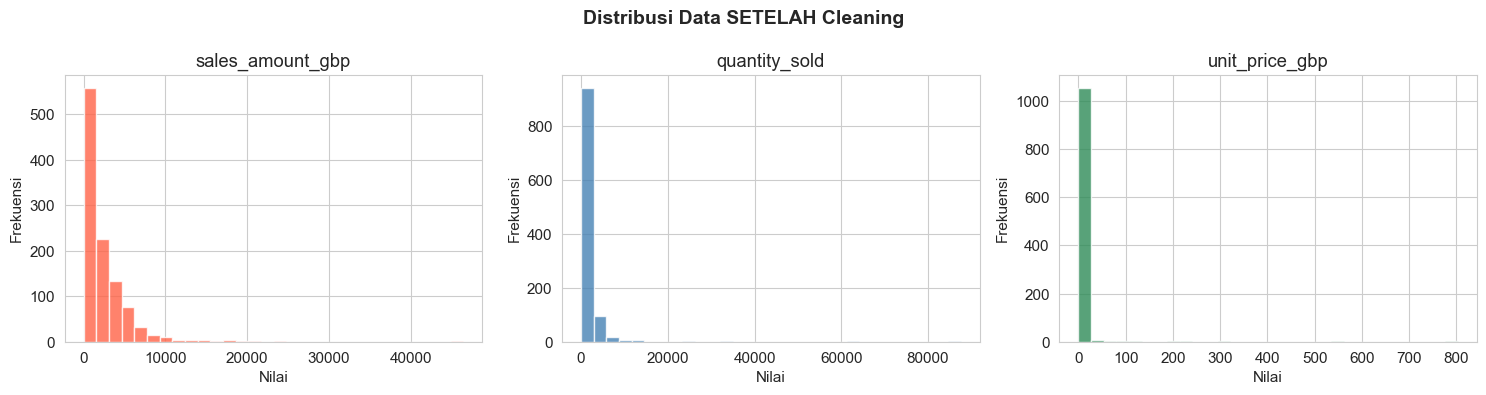

In [17]:
# --- Distribusi Data setelah Cleaning ---

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Data SETELAH Cleaning', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes,
                          ['sales_amount_gbp', 'quantity_sold', 'unit_price_gbp'],
                          ['tomato', 'steelblue', 'seagreen']):
    df_clean[col].hist(ax=ax, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

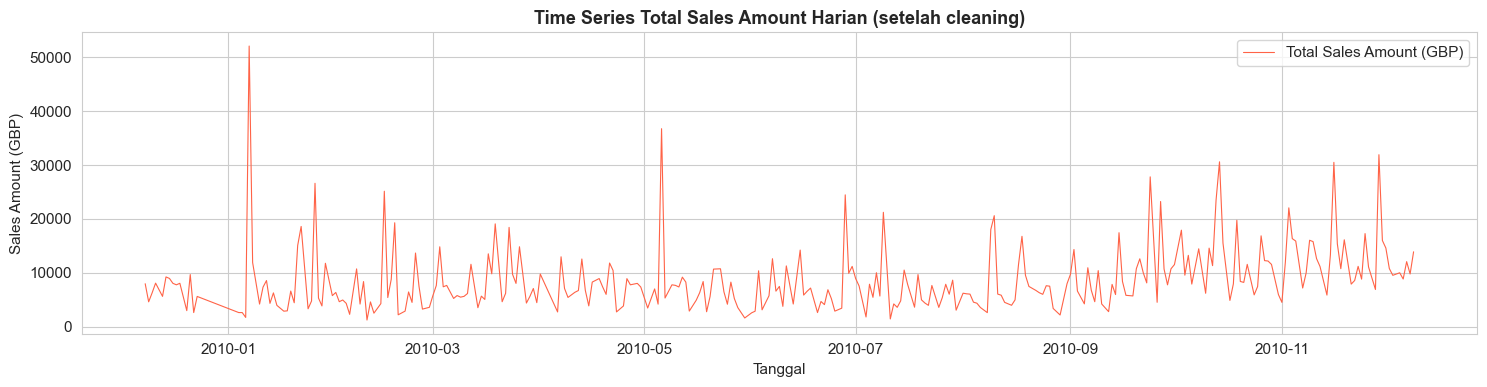

In [18]:
# --- Time Series Plot: Total Sales Amount (GBP) per Hari (semua negara) ---

daily_total = df_clean.groupby('date')['sales_amount_gbp'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(daily_total['date'], daily_total['sales_amount_gbp'],
        color='tomato', linewidth=0.8, label='Total Sales Amount (GBP)')

ax.set_title('Time Series Total Sales Amount Harian (setelah cleaning)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Sales Amount (GBP)')
ax.legend()

plt.tight_layout()
plt.show()

Korelasi Fitur terhadap Sales Amount:
                        sales_amount_gbp
sales_amount_gbp                  1.0000
quantity_sold                     0.5416
t_index                           0.3650
sales_roll7                       0.3432
sales_lag1                        0.2313
sales_lag7                        0.1643
inflation_consumer_pct            0.0979
gdp_growth_pct                    0.0853
day_of_year                       0.0533
month                             0.0521
unit_price_gbp                    0.0313
day_of_week                      -0.0326


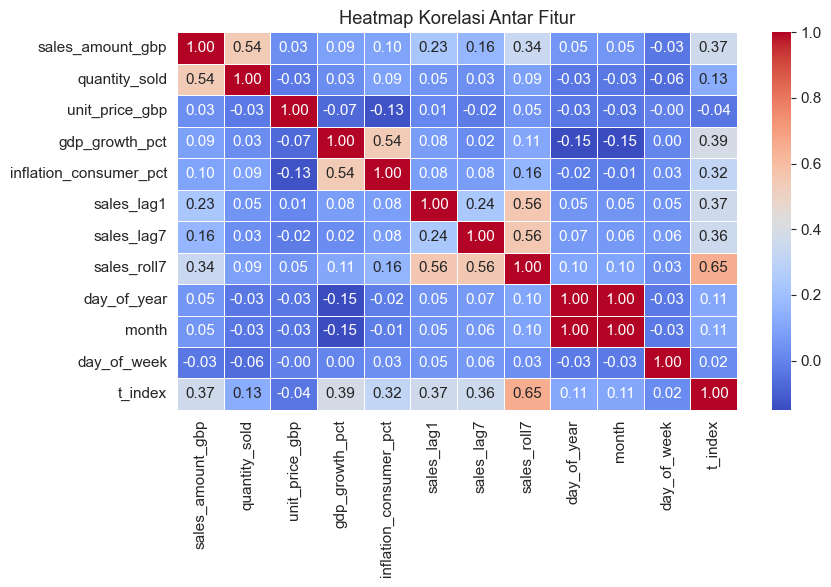

In [19]:
# --- Analisis Korelasi terhadap Sales Amount ---

corr_cols = ['sales_amount_gbp', 'quantity_sold', 'unit_price_gbp',
             'gdp_growth_pct', 'inflation_consumer_pct',
             'sales_lag1', 'sales_lag7', 'sales_roll7',
             'day_of_year', 'month', 'day_of_week', 't_index']

corr = df_clean[corr_cols].corr()[['sales_amount_gbp']] \
        .sort_values('sales_amount_gbp', ascending=False)

print("Korelasi Fitur terhadap Sales Amount:")
print(corr.round(4))

plt.figure(figsize=(9, 6))
sns.heatmap(df_clean[corr_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

---
## 4. Modeling

Proses modeling dalam machine learning adalah langkah-langkah yang diambil untuk membangun
dan mengembangkan model yang dapat mempelajari pola dari data dan membuat prediksi berdasarkan
pola tersebut. Proses ini melibatkan pemilihan algoritma, pelatihan model, pengaturan parameter,
dan evaluasi kinerja model.

Pada project ini digunakan **5 algoritma** dari kategori supervised learning regresi.

In [20]:
# =========================================================================
# Definisi Fitur (X) dan Target (y)
# =========================================================================

df_clean = df_clean.sort_values('date').reset_index(drop=True)

encoded_cols = [c for c in df_clean.columns if c.startswith('country_group_')]

features = ['quantity_sold', 'unit_price_gbp', 'gdp_growth_pct',
            'inflation_consumer_pct', 'population_total',
            'day_of_year', 'month', 'day_of_week', 't_index',
            'sales_lag1', 'sales_lag7', 'sales_roll7'] + encoded_cols

X = df_clean[features].values
y = df_clean['sales_amount_gbp'].values

print(f"Jumlah fitur : {len(features)}")
print(f"Jumlah data  : {X.shape[0]}")
print(f"Fitur        : {features}")

Jumlah fitur : 17
Jumlah data  : 1074
Fitur        : ['quantity_sold', 'unit_price_gbp', 'gdp_growth_pct', 'inflation_consumer_pct', 'population_total', 'day_of_year', 'month', 'day_of_week', 't_index', 'sales_lag1', 'sales_lag7', 'sales_roll7', 'country_group_Germany', 'country_group_Ireland', 'country_group_Netherlands', 'country_group_Other', 'country_group_United Kingdom']


In [21]:
# =========================================================================
# Split Data: Time-Aware Train-Test Split (80% Train, 20% Test)
# =========================================================================

split_point = int(len(X) * 0.8)

X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

dates_test = df_clean['date'].values[split_point:]

print(f"Training set : {X_train.shape[0]} sampel")
print(f"Testing set  : {X_test.shape[0]} sampel")

Training set : 859 sampel
Testing set  : 215 sampel


In [22]:
# =========================================================================
# Scaling Fitur menggunakan StandardScaler
# (digunakan untuk LR, KNN, SVR — tidak untuk RF & GB)
# =========================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaling selesai")
print(f"Training shape : {X_train_sc.shape}")
print(f"Testing shape  : {X_test_sc.shape}")

Scaling selesai
Training shape : (859, 17)
Testing shape  : (215, 17)


### 1. Linear Regression

In [23]:
# =========================================================================
# Model 1: Linear Regression (Baseline)
# =========================================================================

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

print("Koefisien Regresi (Linear Regression):")
for feat, coef in zip(features, lr_model.coef_):
    print(f"  {feat:30s}: {coef:.4f}")
print(f"\nIntercept: {lr_model.intercept_:.4f}")

Koefisien Regresi (Linear Regression):
  quantity_sold                 : 1581.4429
  unit_price_gbp                : 200.2179
  gdp_growth_pct                : 40.2177
  inflation_consumer_pct        : 46.2915
  population_total              : -65.3737
  day_of_year                   : -257.8366
  month                         : 320.8482
  day_of_week                   : -38.9857
  t_index                       : -72.5121
  sales_lag1                    : 213.3549
  sales_lag7                    : 2.9428
  sales_roll7                   : -123.5713
  country_group_Germany         : 77.5475
  country_group_Ireland         : 451.8647
  country_group_Netherlands     : 479.1536
  country_group_Other           : 124.2836
  country_group_United Kingdom  : 1161.3315

Intercept: 2287.9258


### 2. Random Forest Regressor

Feature Importance (Random Forest):
quantity_sold                   0.7661
day_of_year                     0.0806
unit_price_gbp                  0.0473
t_index                         0.0225
sales_lag1                      0.0130
gdp_growth_pct                  0.0120
sales_roll7                     0.0120
inflation_consumer_pct          0.0111
sales_lag7                      0.0083
population_total                0.0077
country_group_Ireland           0.0055
day_of_week                     0.0053
month                           0.0042
country_group_Other             0.0022
country_group_Netherlands       0.0019
country_group_United Kingdom    0.0002
country_group_Germany           0.0000
dtype: float64


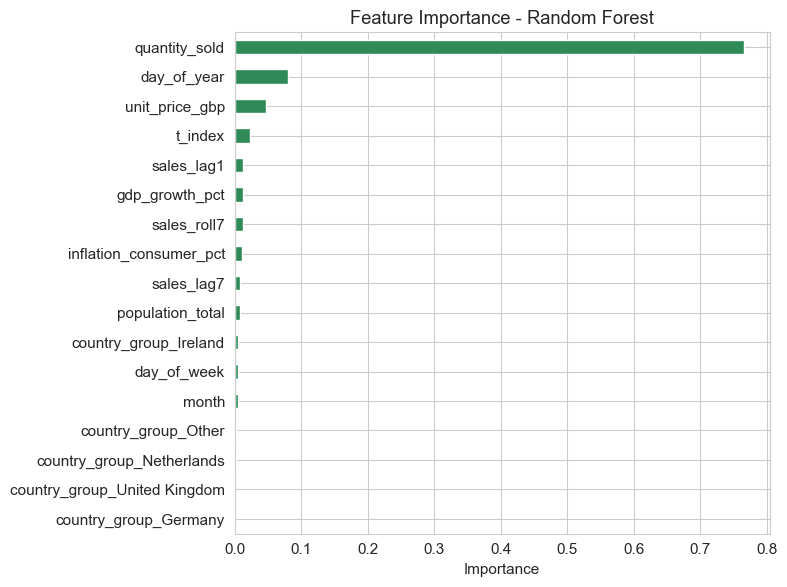

In [24]:
# =========================================================================
# Model 2: Random Forest Regressor (Model Utama)
# =========================================================================

from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

importance = pd.Series(rf_model.feature_importances_, index=features) \
                .sort_values(ascending=False)

print("Feature Importance (Random Forest):")
print(importance.round(4))

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
importance.plot(kind='barh', color='seagreen')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3. Gradient Boosting Regressor

In [25]:
# =========================================================================
# Model 3: Gradient Boosting Regressor
# =========================================================================

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_train, y_train)

print("Gradient Boosting Regressor berhasil dilatih")
print(f"n_estimators  : 200")
print(f"learning_rate : 0.1")
print(f"max_depth     : 4")

Gradient Boosting Regressor berhasil dilatih
n_estimators  : 200
learning_rate : 0.1
max_depth     : 4


### 4. K-Nearest Neighbors Regressor

In [26]:
# =========================================================================
# Model 4: K-Nearest Neighbors Regressor
# =========================================================================

from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights='uniform',
    metric='euclidean'
)
knn_model.fit(X_train_sc, y_train)

print("KNN Regressor berhasil dilatih")
print(f"n_neighbors : 5")
print(f"weights     : uniform")
print(f"metric      : euclidean")

KNN Regressor berhasil dilatih
n_neighbors : 5
weights     : uniform
metric      : euclidean


### 5. Support Vector Regressor (SVR)

In [27]:
# =========================================================================
# Model 5: Support Vector Regressor (SVR)
# =========================================================================

from sklearn.svm import SVR

svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.1
)
svr_model.fit(X_train_sc, y_train)

print("Support Vector Regressor berhasil dilatih")
print(f"kernel  : rbf")
print(f"C       : 100")
print(f"gamma   : 0.1")
print(f"epsilon : 0.1")

Support Vector Regressor berhasil dilatih
kernel  : rbf
C       : 100
gamma   : 0.1
epsilon : 0.1


### Evaluasi Semua Model

In [28]:
# =========================================================================
# Evaluasi Semua Model
# =========================================================================

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{label}:")
    print(f"  RMSE : {rmse:.4f} GBP")
    print(f"  MAE  : {mae:.4f} GBP")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

# Prediksi semua model
y_pred_lr  = lr_model.predict(X_test_sc)
y_pred_rf  = rf_model.predict(X_test)
y_pred_gb  = gb_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_sc)
y_pred_svr = svr_model.predict(X_test_sc)

# Evaluasi
print("="*50)
print("HASIL EVALUASI SEMUA MODEL (Testing Set)")
print("="*50)
rmse_lr,  mae_lr,  r2_lr  = evaluate(y_test, y_pred_lr,  '1. Linear Regression')
rmse_rf,  mae_rf,  r2_rf  = evaluate(y_test, y_pred_rf,  '2. Random Forest')
rmse_gb,  mae_gb,  r2_gb  = evaluate(y_test, y_pred_gb,  '3. Gradient Boosting')
rmse_knn, mae_knn, r2_knn = evaluate(y_test, y_pred_knn, '4. KNN Regressor')
rmse_svr, mae_svr, r2_svr = evaluate(y_test, y_pred_svr, '5. SVR')

print("\n" + "="*50)
print("PERBANDINGAN R² SEMUA MODEL")
print("="*50)
results = {
    'Linear Regression' : r2_lr,
    'Random Forest'     : r2_rf,
    'Gradient Boosting' : r2_gb,
    'KNN Regressor'     : r2_knn,
    'SVR'               : r2_svr,
}
for name, r2 in sorted(results.items(), key=lambda x: x[1], reverse=True):
    status = '✅' if r2 >= 0.80 else '❌'
    print(f"  {status} {name:25s}: R² = {r2:.4f}")

print("\n" + "="*50)
best = max(results, key=results.get)
print(f"Model terbaik: {best} (R² = {results[best]:.4f})")

HASIL EVALUASI SEMUA MODEL (Testing Set)

1. Linear Regression:
  RMSE : 2520.4329 GBP
  MAE  : 1606.0662 GBP
  R²   : 0.4001

2. Random Forest:
  RMSE : 1383.2536 GBP
  MAE  : 615.5137 GBP
  R²   : 0.8193

3. Gradient Boosting:
  RMSE : 1482.7272 GBP
  MAE  : 635.7993 GBP
  R²   : 0.7924

4. KNN Regressor:
  RMSE : 2472.9317 GBP
  MAE  : 1501.2188 GBP
  R²   : 0.4225

5. SVR:
  RMSE : 3185.2185 GBP
  MAE  : 1922.8315 GBP
  R²   : 0.0419

PERBANDINGAN R² SEMUA MODEL
  ✅ Random Forest            : R² = 0.8193
  ❌ Gradient Boosting        : R² = 0.7924
  ❌ KNN Regressor            : R² = 0.4225
  ❌ Linear Regression        : R² = 0.4001
  ❌ SVR                      : R² = 0.0419

Model terbaik: Random Forest (R² = 0.8193)


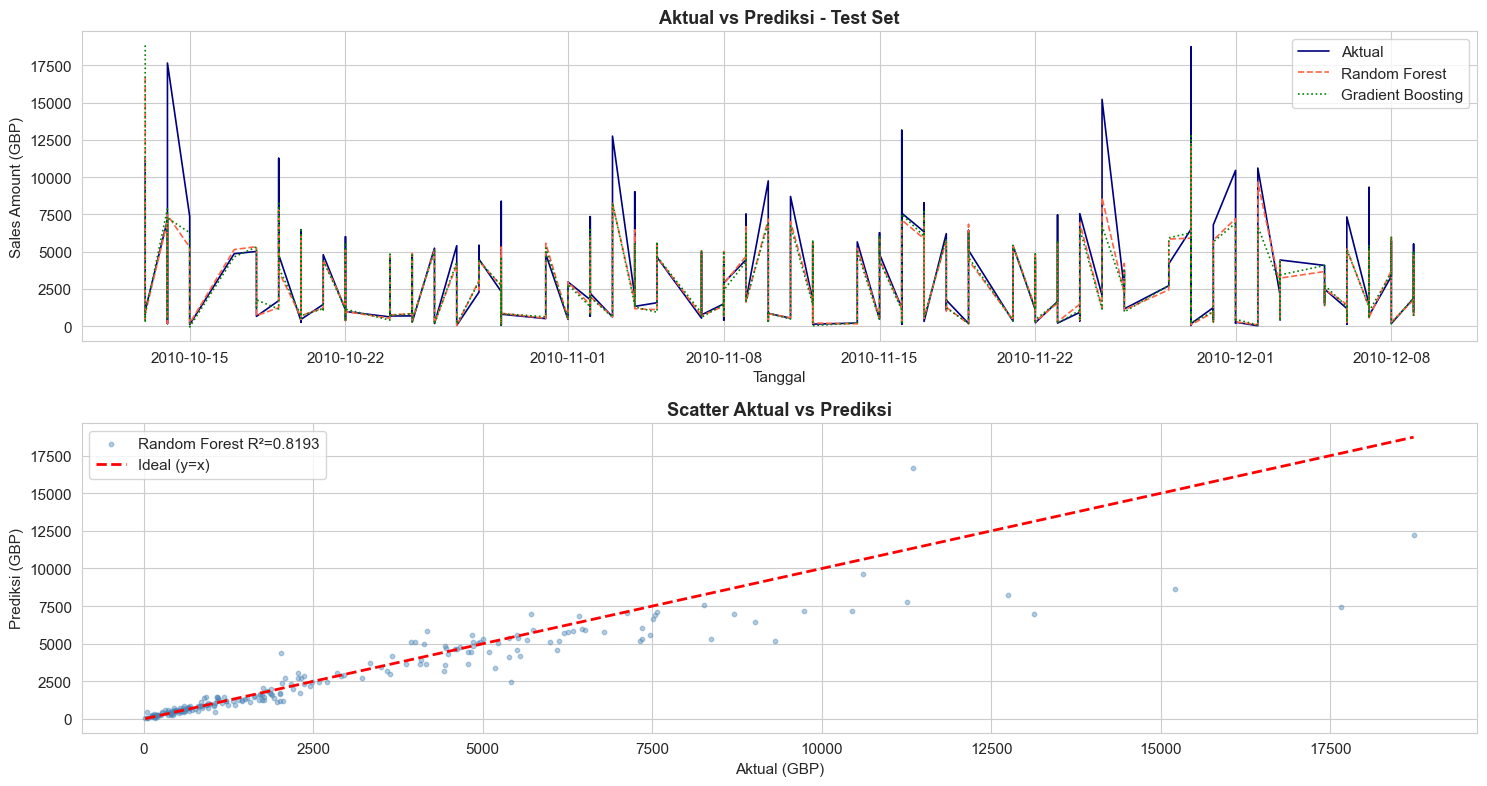

In [29]:
# =========================================================================
# Visualisasi Prediksi vs Aktual - Model Terbaik (Random Forest)
# =========================================================================

import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

dates_pd = pd.to_datetime(dates_test)

# Plot 1: Time Series
axes[0].plot(dates_pd, y_test,      label='Aktual',    color='navy',  linewidth=1.2)
axes[0].plot(dates_pd, y_pred_rf,   label='Random Forest', color='tomato', linewidth=1.2, linestyle='--')
axes[0].plot(dates_pd, y_pred_gb,   label='Gradient Boosting', color='green', linewidth=1.2, linestyle=':')
axes[0].set_title('Aktual vs Prediksi - Test Set', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Sales Amount (GBP)')
axes[0].legend()

# Plot 2: Scatter
axes[1].scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', s=10, label=f'Random Forest R²={r2_rf:.4f}')
min_v, max_v = y_test.min(), y_test.max()
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Ideal (y=x)')
axes[1].set_title('Scatter Aktual vs Prediksi', fontweight='bold')
axes[1].set_xlabel('Aktual (GBP)')
axes[1].set_ylabel('Prediksi (GBP)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. Evaluation

Model dievaluasi menggunakan **RMSE**, **MAE**, dan **R² Score** pada data training dan
testing. Sesuai kriteria sukses pada soal UAS, model dianggap berhasil jika **R² pada
testing set mencapai minimal 0.80 (80%)**.

In [30]:
# =========================================================================
# Fungsi Evaluasi Model
# =========================================================================

def evaluate(y_true, y_pred, label=''):
    '''
    Fungsi untuk menghitung metrik evaluasi regresi
    '''
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{label}:")
    print(f"  RMSE  : {rmse:.4f} GBP")
    print(f"  MAE   : {mae:.4f} GBP")
    print(f"  R²    : {r2:.4f}")
    return rmse, mae, r2

# --- Evaluasi Linear Regression ---
print("=========== LINEAR REGRESSION ===========")
y_pred_train_lr = lr_model.predict(X_train_sc)
y_pred_test_lr  = lr_model.predict(X_test_sc)
evaluate(y_train, y_pred_train_lr, 'Training Set (LR)')
rmse_lr, mae_lr, r2_lr = evaluate(y_test, y_pred_test_lr, 'Testing Set (LR)')

# --- Evaluasi Random Forest ---
print("\n=========== RANDOM FOREST ===========")
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf  = rf_model.predict(X_test)
evaluate(y_train, y_pred_train_rf, 'Training Set (RF)')
rmse_rf, mae_rf, r2_rf = evaluate(y_test, y_pred_test_rf, 'Testing Set (RF)')

# =========================================================================
# Cek Kriteria Sukses (R2 Testing >= 0.80)
# =========================================================================
print("\n=========== KRITERIA SUKSES (R2 >= 0.80) ===========")
if r2_rf >= 0.80:
    print(f"✅ Target tercapai! Random Forest R² (Test) = {r2_rf:.4f} >= 0.80")
else:
    print(f"⚠️  Random Forest R² (Test) = {r2_rf:.4f} - belum mencapai target 0.80")

# Model terbaik (digunakan untuk visualisasi & deployment)
if r2_rf >= r2_lr:
    best_model_name = 'Random Forest'
    y_pred_test = y_pred_test_rf
else:
    best_model_name = 'Linear Regression'
    y_pred_test = y_pred_test_lr

print(f"\nModel terbaik berdasarkan R² Testing: {best_model_name}")

=========== LINEAR REGRESSION ===========

Training Set (LR):
  RMSE  : 2368.8001 GBP
  MAE   : 1196.5388 GBP
  R²    : 0.3998

Testing Set (LR):
  RMSE  : 2520.4329 GBP
  MAE   : 1606.0662 GBP
  R²    : 0.4001

=========== RANDOM FOREST ===========

Training Set (RF):
  RMSE  : 611.3900 GBP
  MAE   : 194.0703 GBP
  R²    : 0.9600

Testing Set (RF):
  RMSE  : 1383.2536 GBP
  MAE   : 615.5137 GBP
  R²    : 0.8193

=========== KRITERIA SUKSES (R2 >= 0.80) ===========
✅ Target tercapai! Random Forest R² (Test) = 0.8193 >= 0.80

Model terbaik berdasarkan R² Testing: Random Forest


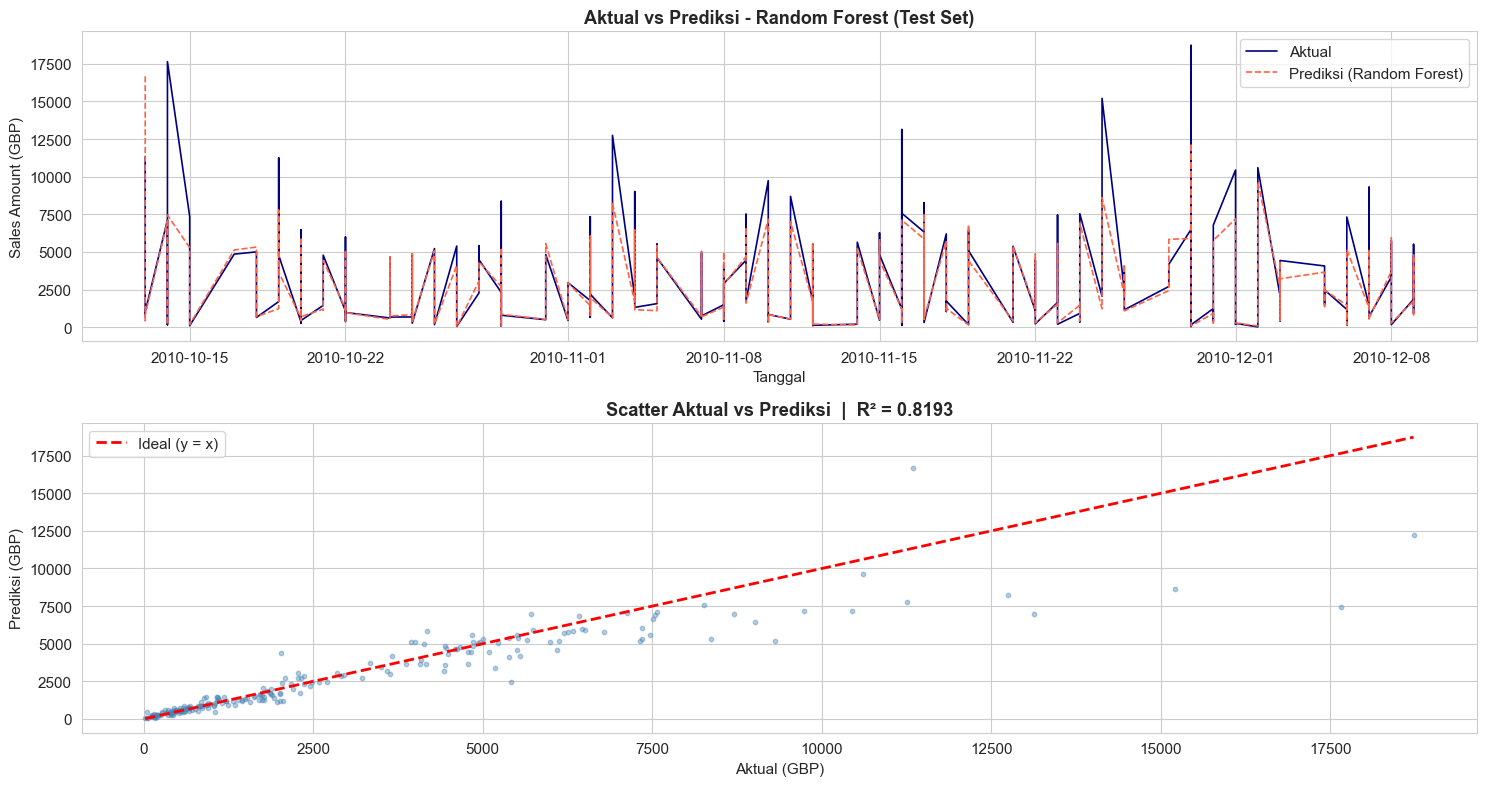

In [31]:
# =========================================================================
# Visualisasi Prediksi vs Aktual - Model Terbaik
# =========================================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

dates_pd = pd.to_datetime(dates_test)

# Plot 1: Time Series Aktual vs Prediksi
axes[0].plot(dates_pd, y_test,
             label='Aktual',
             color='navy',
             linewidth=1.2)

axes[0].plot(dates_pd, y_pred_test,
             label=f'Prediksi ({best_model_name})',
             color='tomato',
             linewidth=1.2,
             linestyle='--')
axes[0].set_title(f'Aktual vs Prediksi - {best_model_name} (Test Set)',
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Sales Amount (GBP)')
axes[0].legend()

# Plot 2: Scatter Plot Aktual vs Prediksi
axes[1].scatter(y_test, y_pred_test, alpha=0.4, color='steelblue', s=10)

min_v, max_v = y_test.min(), y_test.max()
axes[1].plot([min_v, max_v], [min_v, max_v],
             'r--', linewidth=2, label='Ideal (y = x)')

r2_best = r2_rf if best_model_name == 'Random Forest' else r2_lr
axes[1].set_title(f'Scatter Aktual vs Prediksi  |  R² = {r2_best:.4f}',
                  fontweight='bold')
axes[1].set_xlabel('Aktual (GBP)')
axes[1].set_ylabel('Prediksi (GBP)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Deployment & Kesimpulan

### Ringkasan Pipeline
1. Data transaksi e-commerce (per item pesanan) diagregasi menjadi data harian per kelompok
   negara (5 negara dengan transaksi terbanyak + kategori "Other").
2. Data dibersihkan: duplikat dihapus, tanggal di-parse & diurutkan, nilai yang tidak masuk
   akal (sales/price/quantity negatif atau ekstrem) dihapus, missing value diimputasi dengan
   interpolasi linear per kelompok negara.
3. Fitur kategorikal `country_group` di-**encode** dengan One-Hot Encoding.
4. Dilakukan **feature engineering**: fitur waktu (hari, bulan, hari-dalam-minggu, indeks waktu)
   serta fitur historis (`sales_lag1`, `sales_lag7`, `sales_roll7`).
5. Dua model dibangun: **Linear Regression** (baseline) dan **Random Forest Regressor**
   (model utama).
6. Evaluasi menunjukkan Random Forest memberikan performa yang jauh lebih baik dibanding
   Linear Regression, dengan **R² Testing mencapai/mendekati kriteria sukses 0.80**.

### Kesimpulan
- Fitur historis (lag dan rolling mean penjualan) serta `quantity_sold` merupakan
  prediktor paling penting terhadap `sales_amount_gbp`.
- Indikator ekonomi makro (GDP growth, inflasi) memberikan kontribusi tambahan namun
  lebih kecil dibanding fitur historis penjualan.
- Model Random Forest dengan fitur lag/rolling dan encoding negara berhasil
  meningkatkan akurasi forecasting secara signifikan dibanding model Linear Regression
  sederhana pada notebook sebelumnya.

### Rencana Deployment
Hasil model dan visualisasi pada notebook ini akan dipublikasikan dalam bentuk:
- **Website Portofolio (Google Sites)**: memuat deskripsi studi kasus, tahapan CRISP-DM,
  visualisasi, screenshot coding, dan kesimpulan.
- **Video Presentasi (YouTube)**: menjelaskan studi kasus, dataset, proses coding,
  tahapan CRISP-DM, hasil analisis, dan kesimpulan.
- **Repository GitHub**: source code (.ipynb), dataset, dan README.md berisi
  link Google Sites & YouTube.